In [1]:
# LOAD PACKAGES
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from PIL import Image
import geopandas as gpd
from shapely import affinity#, distance
from shapely.geometry import Polygon, Point
import folium
from folium import plugins
from folium.plugins import HeatMap
import osmnx as ox

Image.MAX_IMAGE_PIXELS = None

import networkx as nx

try:
    import matplotlib.pyplot as plt
except ImportError:
    matplotlib.use("agg")
    import matplotlib.pyplot as plt

import pickle
from copy import deepcopy

import branca.colormap as cm
from matplotlib.colors import Normalize
from branca.element import Template, MacroElement

In [2]:
# FUNCTIONS
def visualize_input_graph(G, save = False):
    """ Visualize graph to be partitioned."""

    pos = nx.spring_layout(G)
    nx.draw_networkx_nodes(G, pos, node_size=20, node_color='r', edgecolors='k')
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080')
    # plt.draw()
    if save:
        plt.savefig(output_dir + 'input_graph.png')
    plt.show()
    # plt.close()
    

def visualize_results(G, group_1, group_2, sep_group, illegal_edges, save = False, output_name = 'figures/separator.png'):
    """ Visualize the partition."""

    print("\nVisualizing output...")

    G1 = G.subgraph(group_1)
    G2 = G.subgraph(group_2)
    SG = G.subgraph(sep_group)

    pos_1 = nx.random_layout(G1, center=(-5,0))
    pos_2 = nx.random_layout(G2, center=(5,0))
    pos_sep = nx.random_layout(SG, center=(0,0))
    pos = {**pos_1, **pos_2, **pos_sep}

    nx.draw_networkx_nodes(G, pos_1, node_size=10, nodelist=group_1, node_color='#17bebb', edgecolors='k')
    nx.draw_networkx_nodes(G, pos_2, node_size=10, nodelist=group_2, node_color='#2a7de1', edgecolors='k')
    nx.draw_networkx_nodes(G, pos_sep, node_size=10, nodelist=sep_group, node_color='#f37820', edgecolors='k')

    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080')
    nx.draw_networkx_edges(G, pos, edgelist=illegal_edges, style='solid')

    # plt.draw()
    if save:
        plt.savefig(output_name)
        print("\tOutput stored in", output_name)
    plt.show()
    # plt.close()
    

# Internet Network Case Study

To showcase another use-case of the hubness optimization heuristic, we consider the network separation problem. Given network , one is interested in finding the smallest subset of nodes -- often referred to as the separator group -- the removal of which would result in two disconnected subgraphs, and , of approximately equal sizes. The sizes of the resulting graphs, and , can be controlled by setting an additional constraint, , where is an optimization parameter. The graph separation problem is relevant for epidemic spreading, where one may want to segregate a social network into disconnected graphs, by either vaccinating or isolating a small number of individuals. For computation reasons, We consider a subset of the Internet at the Autonomous System level, consisting of N = 1,000 nodes. 

We first solved the optimization problem using the D-Wave’s Constrained Quadratic solver. The solver found a set of 45 nodes, = 45, separating the network into two subgraphs of approximately equal size (within 1 node of eachother). We next moved on to consider the network separation with termination uncertainty. One aims to sequentially remove n=50 nodes to split the network of interest into two almost equal subgraphs. sizes. The sequence of node removals is supposed to be selected such that if the process terminates at any intermediate step, the number of links connecting the two subgraphs and is as small as possible.

Following the recipe of the hubness heuristic, for each step , we identified separator groups and the two subgraphs for a k. The groups were determined based on idenfying resulting in the smallest numbers of links that would separateing the graph into the two equally sized subgraphs. We then computed hubness of each node based on the frequency the node was found in separator groups, and used hubness values to construct the ordered solution containing nodes with highest hubness values in the decreasing order of hubness. 

These sets have been performed in the notebook '...'. 

To understand these results, in this notebook, we will plot the following results:

    A. The subset of the Internet graph used (N = 1,000 nodes)
    B. Several graphs of the separated graph, showing the two major groups, the separator group and any illegal edges.
        - Specifically we show k = 25, 35, 45
    C. Comparison the Optimality of Different Strategies at Selecting Separators: Compares how n(illegal edges) varies as a function of k in the three cases:
        - The individually optimal strategy for each k aka 'Optimal solution for each number'
        - Selecting the k highest hubness sites aka 'Adding separators in order of hubness'
        - Randomly selecting from the 45 optimal
    D. The subset of the Internet graph used, coloring the nodes based on their hubness values.

In [3]:
# DEFINE OUTPUT LOCATION
output_dir = 'figures/'

# LOAD RESULTS
dir = "data/"

with open(dir+"hubness_list_08-24-2023.pkl", "rb") as fp:   # Unpickling
    hubness_list = pickle.load(fp)

with open(dir+"results_dict_08-24-2023.pkl", "rb") as fp:   # Unpickling
    results_dict = pickle.load(fp)
    
with open(dir+"sorted_hubness_nodes_08-24-2023.pkl", "rb") as fp:   # Unpickling
    sorted_hubness_nodes = pickle.load(fp)

with open(dir+"hubness_results_dict_08-24-2023.pkl", "rb") as fp:   # Unpickling
    hubness_results_dict = pickle.load(fp)

with open(dir+"random_results_dict_08-24-2023.pkl", "rb") as fp:   # Unpickling
    random_results_dict = pickle.load(fp)

## A. Plot the subset of the Internet graph used (N = 1,000 nodes)

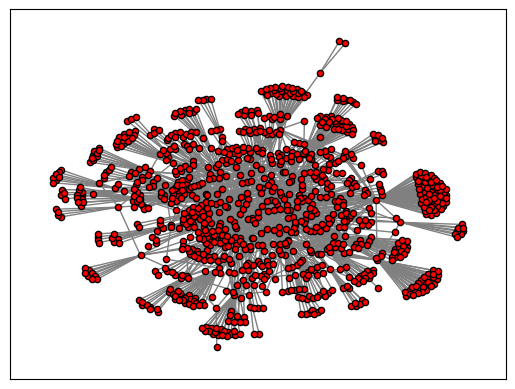

In [4]:
# LOAD GRAPH
# Read previously generated input graph

G = nx.read_gml(dir+"input_graph.gml")

# Saving as gml saves integer node names as strings.
# Convert back to integers for use in functions.
G = nx.relabel_nodes(G, lambda x: int(x))

visualize_input_graph(G, save = True)

### B. Representative Example of the Separated Graph

Several graphs of the separated graph, showing the two major groups, the separator group and any illegal edges. Specifically we show k = 25, 35, 45


Nodes Color Code:

    - The nodes from the first major group are shown in teal. 
    - The nodes from the second major group are shown in blue. 
    - The nodes from the separator group are shown in orange.

Edges Color Code:

    - The edges which connect a node in one of major groups to a separator are shown in grey.
    - Edges which connect nodes within a major group are also shown in grey. 
    - Any edges which connect nodes in one major to a node in the other major group are shown in black.


Visualizing output...
	Output stored in figures/internet_example_k25.png


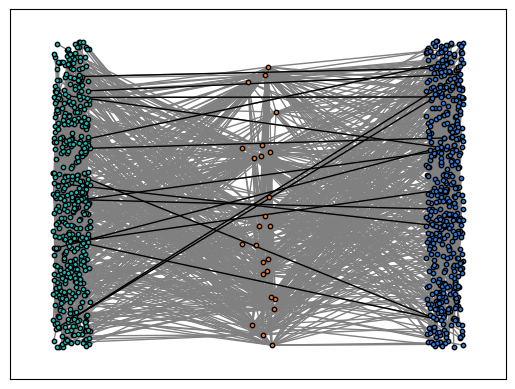

In [5]:
# VISUALIZE GRAPHS
k = 25
mydict = results_dict[k]
group_1 = mydict['group_1']
group_2 = mydict['group_2']
sep_group = mydict['sep_group']
illegal_edges = mydict['illegal_edges']
visualize_results(G, group_1, group_2, sep_group, illegal_edges, save = True, output_name = output_dir + f'internet_example_k{k}.png')


Visualizing output...
	Output stored in figures/internet_example_k35.png


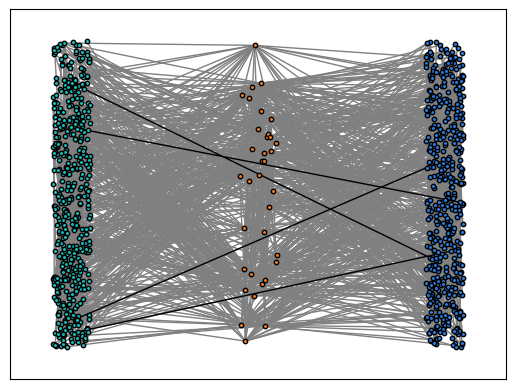

In [6]:
# VISUALIZE GRAPHS
k = 35
mydict = results_dict[k]
group_1 = mydict['group_1']
group_2 = mydict['group_2']
sep_group = mydict['sep_group']
illegal_edges = mydict['illegal_edges']
visualize_results(G, group_1, group_2, sep_group, illegal_edges, save = True, output_name = output_dir + f'internet_example_k{k}.png')


Visualizing output...
	Output stored in figures/internet_example_k45.png


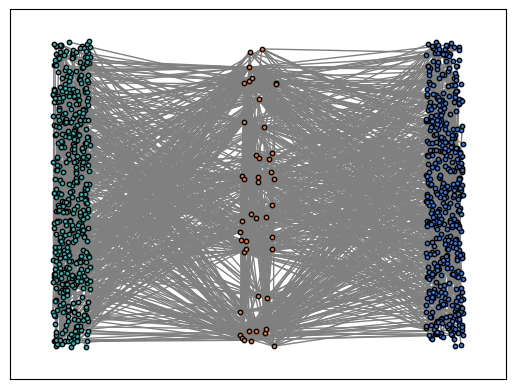

In [7]:
# VISUALIZE GRAPHS
k = 45
mydict = results_dict[k]
group_1 = mydict['group_1']
group_2 = mydict['group_2']
sep_group = mydict['sep_group']
illegal_edges = mydict['illegal_edges']
visualize_results(G, group_1, group_2, sep_group, illegal_edges, save = True, output_name = output_dir + f'internet_example_k{k}.png')

### C. Compare the Optimality of Different Strategies at Selecting Separators: 

Here we will compares how n(illegal edges) varies as a function of k in the three cases:

        - The individually optimal strategy for each k aka 'Optimal solution for each number'
        - Selecting the k highest hubness sites aka 'Adding separators in order of hubness'
        - Randomly selecting from the 45 optimal

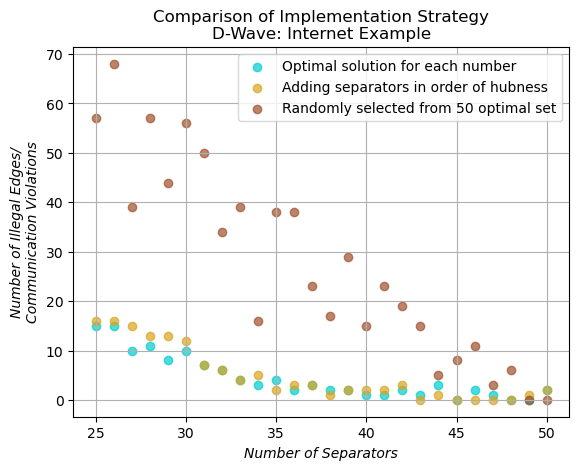

In [8]:
# PLOT UNHAPPINESS
x = range(25, 51)
alpha = 0.7
dwave_unhappiness = [len(results_dict[i]['illegal_edges']) for i in x]
hubness_unhappiness = [len(hubness_results_dict[i]['illegal_edges']) for i in x]
random_unhappiness = [len(random_results_dict[i]['illegal_edges']) for i in x]

plt.scatter(x, dwave_unhappiness, label = 'Optimal solution for each number', alpha = alpha, color = 'darkturquoise')
plt.scatter(x, hubness_unhappiness, label = 'Adding separators in order of hubness', alpha = alpha, color = 'goldenrod')
plt.scatter(x, random_unhappiness, label = 'Randomly selected from 50 optimal set', alpha = alpha, color = 'sienna')

plt.legend()
xlab = plt.xlabel("Number of Separators")
ylab = plt.ylabel("Number of Illegal Edges/\nCommunication Violations")
xlab.set_style('italic')
xlab.set_size(10)
ylab.set_style('italic')
ylab.set_size(10)
plt.title("Comparison of Implementation Strategy\nD-Wave: Internet Example")
plt.grid()
plt.savefig(output_dir + "internet_example_unhappiness.png")
plt.show()

### D. Plot subset of the Internet graph used, color coding the nodes based on their hubness values

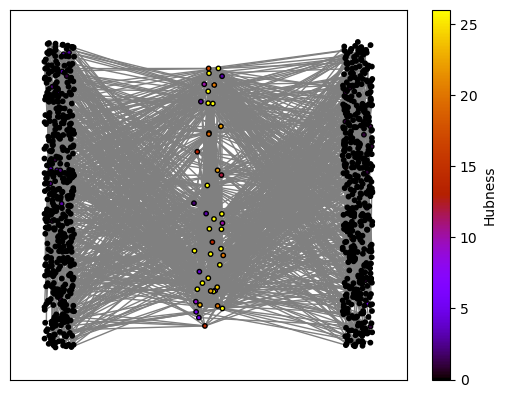

In [9]:
k = 45
mydict = results_dict[k]
group_1 = mydict['group_1']
group_2 = mydict['group_2']
sep_group = mydict['sep_group']
illegal_edges = mydict['illegal_edges']

G1 = G.subgraph(group_1)
G2 = G.subgraph(group_2)
SG = G.subgraph(sep_group)

pos_1 = nx.random_layout(G1, center=(-5,0))
pos_2 = nx.random_layout(G2, center=(5,0))
pos_sep = nx.random_layout(SG, center=(0,0))
pos = {**pos_1, **pos_2, **pos_sep}

nc = nx.draw_networkx_nodes(G, pos, node_size=10, node_color=hubness_list, cmap=plt.cm.gnuplot, edgecolors='k')
plt.colorbar(nc, label = "Hubness")

nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080')
nx.draw_networkx_edges(G, pos, edgelist=illegal_edges, style='solid')
# plt.savefig(output_dir + "internet_example_separated_graph_with_hubness.png")
plt.show()

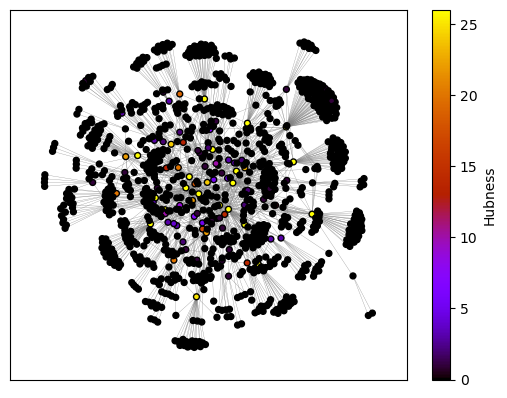

In [14]:
# This one
pos = nx.spring_layout(G)
max_hubness = max(hubness_list)
nc = nx.draw_networkx_nodes(G, pos, node_size=18, node_color=hubness_list, cmap=plt.cm.gnuplot, edgecolors='k')
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080', width=0.2)
plt.colorbar(nc, label = "Hubness")
plt.savefig(output_dir + "internet_example_graph_with_hubness.png")
plt.show()

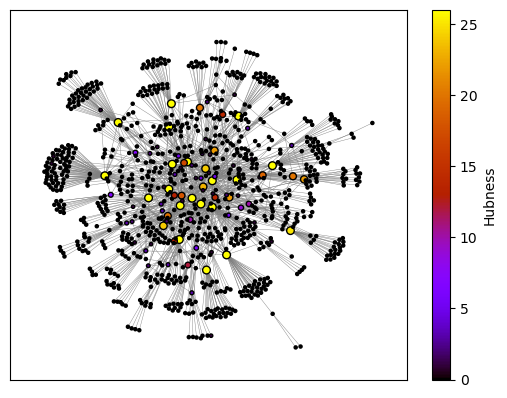

In [11]:
pos = nx.spring_layout(G)
max_hubness = max(hubness_list)
nc = nx.draw_networkx_nodes(G, pos, node_size=[5+x for x in hubness_list], node_color=hubness_list, cmap=plt.cm.gnuplot, edgecolors='k')
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080', width=0.3)
plt.colorbar(nc, label = "Hubness")
plt.savefig(output_dir + "internet_example_graph_with_hubness.png")
plt.show()

/home/kelseystoddard/Programs/miniconda3/envs/ctc/lib/python3.9/site-packages/networkx/drawing/nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(
/tmp/ipykernel_98738/2744109993.py:5: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=max_hubness), cmap=plt.cm.gnuplot), label = "Hubness")


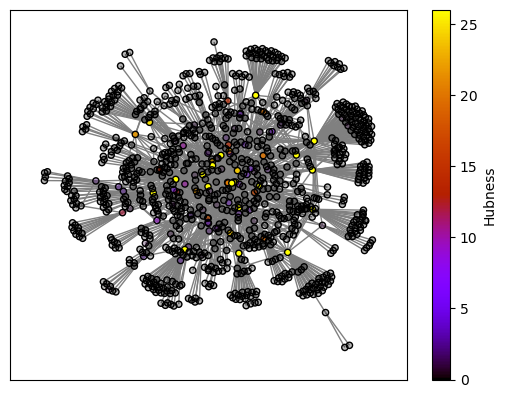

In [12]:
pos = nx.spring_layout(G)
max_hubness = max(hubness_list)
nc = nx.draw_networkx_nodes(G, pos, node_size=20, node_color=hubness_list, cmap=plt.cm.gnuplot, alpha = [(x+10)/(max_hubness+10) for x in hubness_list], edgecolors='k')
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080')
plt.colorbar(plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=max_hubness), cmap=plt.cm.gnuplot), label = "Hubness")
# plt.savefig("internet_example_graph_with_hubness_alpha.png")
plt.show()